**Matematik - Doğrusal Cebir**

*Doğrusal cebir, vektör uzaylarını ve bu uzaylar arasındaki doğrusal dönüşümleri inceleyen matematik dalıdır; örneğin bir şekli döndürmek, büyütmek/küçültmek ya da ötelemek gibi.*

*Makine öğrenmesi doğrusal cebire çok dayanır. Bu yüzden vektörlerin ve matrislerin ne olduğunu, bunlarla hangi işlemleri yapabildiğimizi ve neden işimize yaradıklarını anlamak önemli.*

# Vektörler
## Tanım
Bir vektör, büyüklük ve yön ile tanımlanan bir niceliktir. Örneğin bir roketin hızı 3 boyutlu bir vektördür: büyüklüğü roketin sürati, yönü ise (umarım) yukarı doğrudur. Bir vektör, *skaler* denilen sayı dizileriyle temsil edilebilir. Her skaler, vektörün ilgili boyuttaki büyüklüğünü gösterir.

Örneğin roket hafif bir açıyla yukarı gidiyorsa: dikey hızı 5.000 m/s, Doğu yönünde 10 m/s ve Kuzey yönünde 50 m/s hızı vardır. Roketin hızı şu vektörle temsil edilebilir:

**hız** $= \begin{pmatrix}
10 \\
50 \\
5000 \\
\end{pmatrix}$

Not: geleneksel olarak vektörler sütun biçiminde gösterilir. Ayrıca vektör adları genellikle küçük harfle yazılır; böylece matrislerden (aşağıda ele alacağız) ve basit skaler değerlerden ayrılırlar. Mümkün olduğunda kalın yazılır; örneğin ${metre\_saniye} = 5026$ gibi bir skalerden farklı oldukları anlaşılır.

N elemanlı bir liste, N boyutlu uzayda bir noktanın koordinatlarını da temsil edebilir; bu yüzden vektörleri oklar yerine bazen nokta olarak gösteririz. 1 elemanlı vektör bir eksende ok veya nokta, 2 elemanlı vektör düzlemde ok veya nokta, 3 elemanlı vektör uzayda ok veya nokta, N elemanlı vektör ise N boyutlu uzayda bir ok veya noktadır… ki çoğu insan bunu hayal etmekte zorlanır.

## Makine öğrenmesinde kullanımı
Vektörlerin makine öğrenmesinde birçok kullanımı vardır; en belirgin olanı gözlemleri ve tahminleri temsil etmektir. Örneğin videoları 3 kategoriye (iyi, spam, tıklama tuzağı) ayıran bir makine öğrenmesi sistemi kurduğumuzu varsayalım. Her video için elimizdeki bilgileri temsil eden bir vektör olur:

**video** $= \begin{pmatrix}
10.5 \\
5.2 \\
3.25 \\
7.0
\end{pmatrix}$

Bu vektör 10,5 dakika süren, izleyicilerin yalnızca %5,2'sinin bir dakikadan fazla izlediği, günde ortalama 3,25 görüntülenme alan ve 7 kez spam olarak işaretlenen bir videoyu temsil edebilir. Gördüğünüz gibi her eksen farklı bir anlama gelebilir.

Bu vektöre dayanarak sistemimiz videonun %80 spam, %18 tıklama tuzağı ve %2 iyi video olma olasılığını tahmin edebilir. Bu şu vektörle temsil edilebilir:

**sınıf_olasılıkları** $= \begin{pmatrix}
0.80 \\
0.18 \\
0.02
\end{pmatrix}$

## Python'da vektörler
Python'da bir vektör birçok şekilde temsil edilebilir; en basiti normal bir Python sayı listesidir:

In [1]:
[10.5, 5.2, 3.25, 7.0]

[10.5, 5.2, 3.25, 7.0]

Biraz hesaplama yapacağımız için, vektörler üzerinde temel matematiksel işlemleri hazır ve verimli şekilde sunan NumPy'nin `ndarray` yapısını kullanmak daha iyi. Örneğin:

In [2]:
import numpy as np
video = np.array([10.5, 5.2, 3.25, 7.0])
video

array([10.5 ,  5.2 ,  3.25,  7.  ])

Bir vektörün boyutunu `size` özelliğiyle öğrenebiliriz:

In [3]:
video.size

4

$\textbf{v}$ vektörünün $i$'inci elemanı (bazen *girdi* veya *öğe* de denir) $\textbf{v}_i$ ile gösterilir.

Matematikte indisler genellikle 1'den başlar, programlamada ise 0'dan. Dolayısıyla $\textbf{video}_3$'e programda erişmek için şunu yazarız:

In [4]:
video[2]  # 3. eleman

np.float64(3.25)

## Vektörleri çizdirmek
Vektörleri çizdirmek için matplotlib kullanacağız; önce onu içe aktaralım:

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

### 2B vektörler
Çizmek için birkaç basit 2B vektör oluşturalım:

In [6]:
u = np.array([2, 5])
v = np.array([3, 1])

Bu vektörlerin her biri 2 elemanlı olduğu için 2B bir grafikte kolayca nokta olarak gösterilebilir:

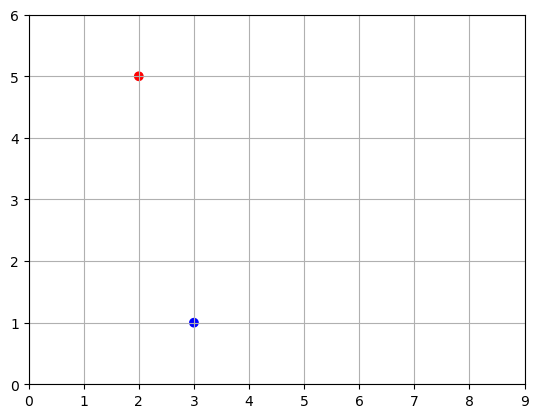

In [7]:
x_coords, y_coords = zip(u, v)
plt.scatter(x_coords, y_coords, color=["r","b"])
plt.axis([0, 9, 0, 6])
plt.grid()
plt.show()

Vektörleri ok olarak da çizebiliriz. Bunun için küçük bir yardımcı fonksiyon oluşturalım:

In [8]:
def plot_vector2d(vector2d, origin=[0, 0], **options):
    return plt.arrow(origin[0], origin[1], vector2d[0], vector2d[1],
              head_width=0.2, head_length=0.3, length_includes_head=True,
              **options)

Şimdi **u** ve **v** vektörlerini ok olarak çizelim:

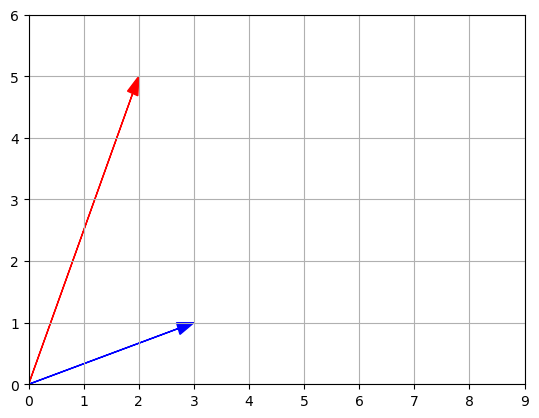

In [9]:
plot_vector2d(u, color="r")
plot_vector2d(v, color="b")
plt.axis([0, 9, 0, 6])
plt.grid()
plt.show()

### 3B vektörler
3B vektörleri çizmek de oldukça kolay. Önce iki 3B vektör oluşturalım:

In [10]:
a = np.array([1, 2, 8])
b = np.array([5, 6, 3])

Şimdi matplotlib'in `Axes3D` sınıfını kullanarak çizelim:

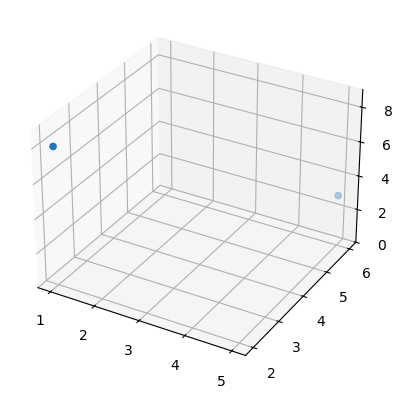

In [11]:
from mpl_toolkits.mplot3d import Axes3D

subplot3d = plt.subplot(111, projection='3d')
x_coords, y_coords, z_coords = zip(a,b)
subplot3d.scatter(x_coords, y_coords, z_coords)
subplot3d.set_zlim3d([0, 9])
plt.show()

Bu iki noktanın uzayda tam olarak nerede olduğunu görmek biraz zor; dikey çizgiler ekleyelim. Dikey çizgili 3B vektör listesi çizmek için küçük bir yardımcı fonksiyon yazalım:

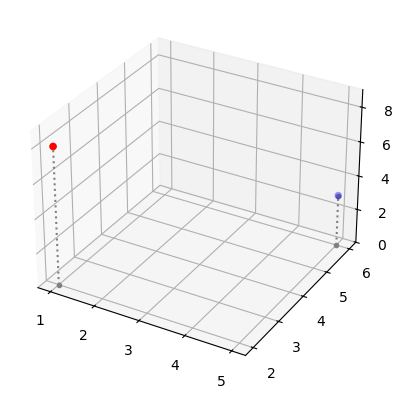

In [12]:
def plot_vectors3d(ax, vectors3d, z0, **options):
    for v in vectors3d:
        x, y, z = v
        ax.plot([x,x], [y,y], [z0, z], color="gray", linestyle='dotted', marker=".")
    x_coords, y_coords, z_coords = zip(*vectors3d)
    ax.scatter(x_coords, y_coords, z_coords, **options)

subplot3d = plt.subplot(111, projection='3d')
subplot3d.set_zlim([0, 9])
plot_vectors3d(subplot3d, [a,b], 0, color=("r","b"))
plt.show()

## Norm
$\textbf{u}$ vektörünün normu $\left \Vert \textbf{u} \right \|$ ile gösterilir ve $\textbf{u}$'nun uzunluğunu (büyüklüğünü) ölçer. Birden fazla norm tanımı vardır; en yaygın olanı (ve burada ele alacağımız tek norm) Öklid normudur:

$\left \Vert \textbf{u} \right \| = \sqrt{\sum_{i}{\textbf{u}_i}^2}$

Bunu saf Python'da kolayca yazabiliriz; $\sqrt x = x^{\frac{1}{2}}$ olduğunu hatırlayarak:

In [13]:
def vector_norm(vector):
    squares = [element**2 for element in vector]
    return sum(squares)**0.5

print("||", u, "|| =")
vector_norm(u)

|| [2 5] || =


np.float64(5.385164807134504)

Ama bunun yerine NumPy'nin `linalg` modülündeki `norm` fonksiyonunu kullanmak çok daha verimli:

In [14]:
import numpy.linalg as LA
LA.norm(u)

np.float64(5.385164807134504)

$\textbf{v}$ vektörünün uzunluğunun gerçekten $\approx 5.4$ olduğunu doğrulamak için küçük bir şema çizelim:

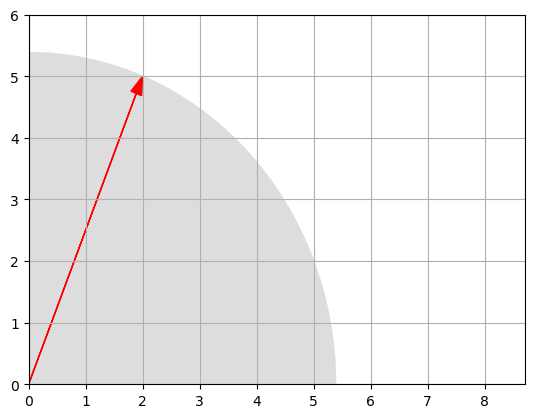

In [15]:
radius = LA.norm(u)
plt.gca().add_artist(plt.Circle((0,0), radius, color="#DDDDDD"))
plot_vector2d(u, color="red")
plt.axis([0, 8.7, 0, 6])
plt.grid()
plt.show()

Gayet doğru görünüyor!

## Toplama
Aynı boyuttaki vektörler toplanabilir. Toplama işlemi *eleman bazında* yapılır:

In [16]:
print(" ", u)
print("+", v)
print("-"*10)
u + v

  [2 5]
+ [3 1]
----------


array([5, 6])

Vektör toplamının grafiksel olarak nasıl göründüğüne bakalım:

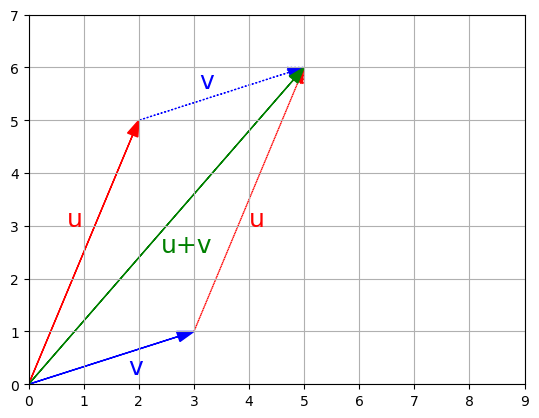

In [17]:
plot_vector2d(u, color="r")
plot_vector2d(v, color="b")
plot_vector2d(v, origin=u, color="b", linestyle="dotted")
plot_vector2d(u, origin=v, color="r", linestyle="dotted")
plot_vector2d(u+v, color="g")
plt.axis([0, 9, 0, 7])
plt.text(0.7, 3, "u", color="r", fontsize=18)
plt.text(4, 3, "u", color="r", fontsize=18)
plt.text(1.8, 0.2, "v", color="b", fontsize=18)
plt.text(3.1, 5.6, "v", color="b", fontsize=18)
plt.text(2.4, 2.5, "u+v", color="g", fontsize=18)
plt.grid()
plt.show()

Vektör toplamı **değişme özelliğine** sahiptir: $\textbf{u} + \textbf{v} = \textbf{v} + \textbf{u}$. Önceki şekilde görebilirsiniz: önce $\textbf{u}$ sonra $\textbf{v}$ takip etmek, önce $\textbf{v}$ sonra $\textbf{u}$ takip etmekle aynı noktaya götürür.

Vektör toplamı **birleşme özelliğine** de sahiptir: $\textbf{u} + (\textbf{v} + \textbf{w}) = (\textbf{u} + \textbf{v}) + \textbf{w}$.

Bir şekil bir dizi nokta (vektör) ile tanımlıysa ve bu noktaların hepsine $\textbf{v}$ vektörünü eklerseniz, tüm şekil $\textbf{v}$ kadar kayar. Buna **geometrik öteleme** denir:

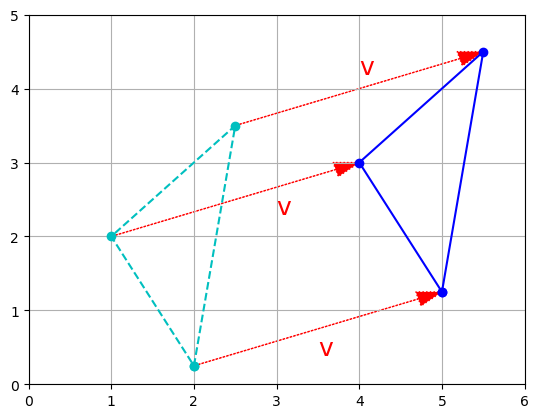

In [18]:
t1 = np.array([2, 0.25])
t2 = np.array([2.5, 3.5])
t3 = np.array([1, 2])

x_coords, y_coords = zip(t1, t2, t3, t1)
plt.plot(x_coords, y_coords, "c--", x_coords, y_coords, "co")

plot_vector2d(v, t1, color="r", linestyle=":")
plot_vector2d(v, t2, color="r", linestyle=":")
plot_vector2d(v, t3, color="r", linestyle=":")

t1b = t1 + v
t2b = t2 + v
t3b = t3 + v

x_coords_b, y_coords_b = zip(t1b, t2b, t3b, t1b)
plt.plot(x_coords_b, y_coords_b, "b-", x_coords_b, y_coords_b, "bo")

plt.text(4, 4.2, "v", color="r", fontsize=18)
plt.text(3, 2.3, "v", color="r", fontsize=18)
plt.text(3.5, 0.4, "v", color="r", fontsize=18)

plt.axis([0, 6, 0, 5])
plt.grid()
plt.show()

Son olarak, bir vektörü çıkarmak ters vektörü eklemekle aynıdır.

## Bir skalerle çarpma
Vektörler skalerlerle çarpılabilir. Vektörün tüm elemanları o sayı ile çarpılır, örneğin:

In [19]:
print("1.5 *", u, "=")

1.5 * u

1.5 * [2 5] =


array([3. , 7.5])

Grafiksel olarak skaler ile çarpma, şeklin ölçeğini değiştirir; adını da buradan alır. Orijinden (koordinatları sıfır olan nokta) uzaklık da skalerle çarpılır. Örneğin `k = 2.5` katsayısıyla büyütelim:

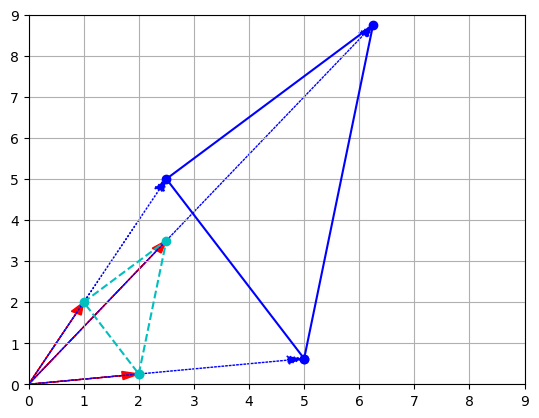

In [20]:
k = 2.5
t1c = k * t1
t2c = k * t2
t3c = k * t3

plt.plot(x_coords, y_coords, "c--", x_coords, y_coords, "co")

plot_vector2d(t1, color="r")
plot_vector2d(t2, color="r")
plot_vector2d(t3, color="r")

x_coords_c, y_coords_c = zip(t1c, t2c, t3c, t1c)
plt.plot(x_coords_c, y_coords_c, "b-", x_coords_c, y_coords_c, "bo")

plot_vector2d(k * t1, color="b", linestyle=":")
plot_vector2d(k * t2, color="b", linestyle=":")
plot_vector2d(k * t3, color="b", linestyle=":")

plt.axis([0, 9, 0, 9])
plt.grid()
plt.show()

Tahmin edebileceğiniz gibi, bir vektörü bir skalerle bölmek onun tersini almakla çarpmaya eşdeğerdir:

$\dfrac{\textbf{u}}{\lambda} = \dfrac{1}{\lambda} \times \textbf{u}$

Skaler ile çarpma **değişme özelliğine** sahiptir: $\lambda \times \textbf{u} = \textbf{u} \times \lambda$.

**Birleşme özelliğine** de sahiptir: $\lambda_1 \times (\lambda_2 \times \textbf{u}) = (\lambda_1 \times \lambda_2) \times \textbf{u}$.

Son olarak vektör toplamı üzerinde **dağılma özelliği** gösterir: $\lambda \times (\textbf{u} + \textbf{v}) = \lambda \times \textbf{u} + \lambda \times \textbf{v}$.

## Sıfır, birim ve normalize vektörler
* **Sıfır vektör**, tüm elemanları 0 olan vektördür.
* **Birim vektör**, normu 1 olan vektördür.
* Sıfır olmayan $\textbf{u}$ vektörünün **normalize vektörü** $\hat{\textbf{u}}$ ile gösterilir; $\textbf{u}$ ile aynı yönü gösteren birim vektördür: $\hat{\textbf{u}} = \dfrac{\textbf{u}}{\left \Vert \textbf{u} \right \|}$

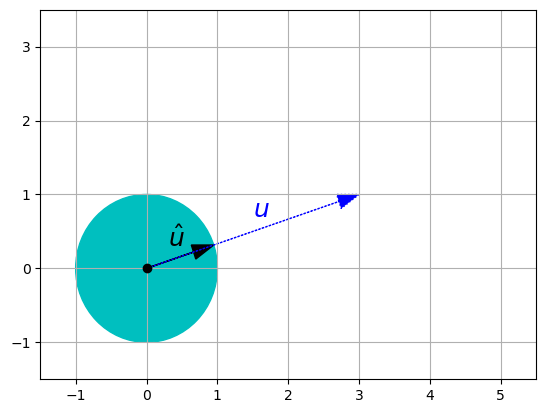

In [21]:
plt.gca().add_artist(plt.Circle((0,0),1,color='c'))
plt.plot(0, 0, "ko")
plot_vector2d(v / LA.norm(v), color="k")
plot_vector2d(v, color="b", linestyle=":")
plt.text(0.3, 0.3, "$\hat{u}$", color="k", fontsize=18)
plt.text(1.5, 0.7, "$u$", color="b", fontsize=18)
plt.axis([-1.5, 5.5, -1.5, 3.5])
plt.grid()
plt.show()

## İç çarpım
### Tanım
İki vektör $\textbf{u}$ ve $\textbf{v}$ arasındaki iç çarpım (Öklid uzayında bazen *skaler çarpım* da denir), doğrusal cebirde sık karşılaşılan kullanışlı bir işlemdir. $\textbf{u} \cdot \textbf{v}$, bazen $⟨\textbf{u}|\textbf{v}⟩$ veya $(\textbf{u}|\textbf{v})$ ile gösterilir ve şöyle tanımlanır:

$\textbf{u} \cdot \textbf{v} = \left \Vert \textbf{u} \right \| \times \left \Vert \textbf{v} \right \| \times cos(\theta)$

burada $\theta$, $\textbf{u}$ ile $\textbf{v}$ arasındaki açıdır.

İç çarpımı hesaplamanın bir başka yolu:

$\textbf{u} \cdot \textbf{v} = \sum_i{\textbf{u}_i \times \textbf{v}_i}$

### Python'da
İç çarpımı yazmak oldukça kolaydır:

In [22]:
def dot_product(v1, v2):
    return sum(v1i * v2i for v1i, v2i in zip(v1, v2))

dot_product(u, v)

np.int64(11)

Ama NumPy bunun için çok daha verimli bir `dot` fonksiyonu sunar:

In [23]:
np.dot(u,v)

np.int64(11)

İsterseniz `ndarray` nesnelerinin `dot` metodunu da kullanabilirsiniz:

In [24]:
u.dot(v)

np.int64(11)

**Dikkat**: `*` operatörü iç çarpım değil, *eleman bazlı* çarpma yapar:

In [25]:
print("  ",u)
print("* ",v, "(NOT a dot product)")
print("-"*10)

u * v

   [2 5]
*  [3 1] (NOT a dot product)
----------


array([6, 5])

### Temel özellikler
* İç çarpım **değişme özelliğine** sahiptir: $\textbf{u} \cdot \textbf{v} = \textbf{v} \cdot \textbf{u}$.
* İç çarpım yalnızca iki vektör arasında tanımlıdır; skaler ile vektör arasında tanımlı değildir. Bu yüzden iç çarpımları zincirleyemeyiz: örneğin $\textbf{u} \cdot \textbf{v} \cdot \textbf{w}$ ifadesi tanımsızdır çünkü $\textbf{u} \cdot \textbf{v}$ bir skaler, $\textbf{w}$ ise bir vektördür.
* Bu aynı zamanda iç çarpımın **birleşme özelliğine sahip olmadığı** anlamına gelir: $(\textbf{u} \cdot \textbf{v}) \cdot \textbf{w} ≠ \textbf{u} \cdot (\textbf{v} \cdot \textbf{w})$ — ikisi de tanımsızdır.
* Ancak iç çarpım, skaler ile çarpma ile birlikte **birleşme özelliği** gösterir: $\lambda \times (\textbf{u} \cdot \textbf{v}) = (\lambda \times \textbf{u}) \cdot \textbf{v} = \textbf{u} \cdot (\lambda \times \textbf{v})$
* Son olarak iç çarpım, vektör toplamı üzerinde **dağılma özelliği** gösterir: $\textbf{u} \cdot (\textbf{v} + \textbf{w}) = \textbf{u} \cdot \textbf{v} + \textbf{u} \cdot \textbf{w}$.

### Vektörler arasındaki açıyı hesaplama
İç çarpımın kullanım alanlarından biri, sıfır olmayan iki vektör arasındaki açıyı bulmaktır. İç çarpım tanımına bakarak şu formülü çıkarabiliriz:

$\theta = \arccos{\left ( \dfrac{\textbf{u} \cdot \textbf{v}}{\left \Vert \textbf{u} \right \| \times \left \Vert \textbf{v} \right \|} \right ) }$

$\textbf{u} \cdot \textbf{v} = 0$ ise $\theta = \dfrac{π}{2}$ olur. Başka bir deyişle, iki sıfır olmayan vektörün iç çarpımı sıfırsa diklerdir.

Bu formülü $\textbf{u}$ ile $\textbf{v}$ arasındaki açıyı (radyan cinsinden) hesaplamak için kullanalım:

In [26]:
def vector_angle(u, v):
    cos_theta = u.dot(v) / LA.norm(u) / LA.norm(v)
    return np.arccos(np.clip(cos_theta, -1, 1))

theta = vector_angle(u, v)
print("Angle =", theta, "radians")
print("      =", theta * 180 / np.pi, "degrees")

Angle = 0.8685393952858895 radians
      = 49.76364169072618 degrees


Not: Küçük kayan nokta hataları nedeniyle `cos_theta` değeri çok az da olsa $[-1, 1]$ aralığının dışına çıkabilir; bu durumda `arccos` hata verebilir. Bu yüzden değeri NumPy'nin `clip` fonksiyonuyla aralığa sıkıştırdık.

### Bir noktayı eksene projeksiyon
İç çarpım, noktaları bir eksene projekte etmek için de çok kullanışlıdır. $\textbf{v}$ vektörünün $\textbf{u}$ eksenine projeksiyonu şu formülle verilir:

$\textbf{proj}_{\textbf{u}}{\textbf{v}} = \dfrac{\textbf{u} \cdot \textbf{v}}{\left \Vert \textbf{u} \right \| ^2} \times \textbf{u}$

Bu da şuna eşdeğerdir:

$\textbf{proj}_{\textbf{u}}{\textbf{v}} = (\textbf{v} \cdot \hat{\textbf{u}}) \times \hat{\textbf{u}}$

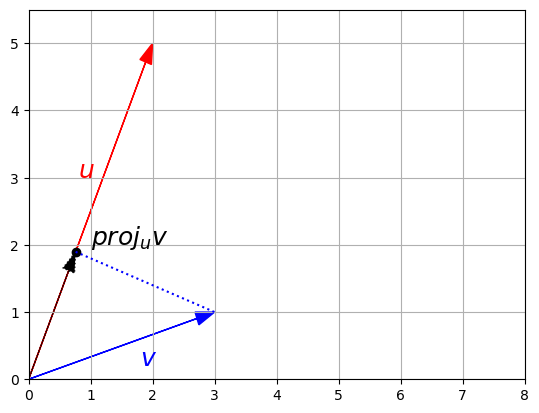

In [27]:
u_normalized = u / LA.norm(u)
proj = v.dot(u_normalized) * u_normalized

plot_vector2d(u, color="r")
plot_vector2d(v, color="b")

plot_vector2d(proj, color="k", linestyle=":")
plt.plot(proj[0], proj[1], "ko")

plt.plot([proj[0], v[0]], [proj[1], v[1]], "b:")

plt.text(1, 2, "$proj_u v$", color="k", fontsize=18)
plt.text(1.8, 0.2, "$v$", color="b", fontsize=18)
plt.text(0.8, 3, "$u$", color="r", fontsize=18)

plt.axis([0, 8, 0, 5.5])
plt.grid()
plt.show()

# Matrisler
Matris, satır ve sütunlar halinde düzenlenmiş skalerlerden (yani tam, reel veya karmaşık sayı) oluşan dikdörtgen bir tablodur, örneğin:

\begin{bmatrix} 10 & 20 & 30 \\ 40 & 50 & 60 \end{bmatrix}

Bir matrisi vektör listesi olarak da düşünebilirsiniz: yukarıdaki matris ya 2 yatay 3B vektör ya da 3 dikey 2B vektör içerir.

Matrisler birçok vektör üzerinde aynı anda işlem yapmak için uygun ve çok verimlidir. Ayrıca döndürme, öteleme ve ölçekleme gibi doğrusal dönüşümleri temsil etmek ve uygulamak için de mükemmeldir.

## Python'da matrisler
Python'da bir matris farklı şekillerde temsil edilebilir. En basit yol, iç içe Python listeleri kullanmaktır:

In [28]:
[
    [10, 20, 30],
    [40, 50, 60]
]

[[10, 20, 30], [40, 50, 60]]

Daha verimli bir yol ise, birçok matris işlemini optimize edilmiş şekilde sunan NumPy kütüphanesini kullanmaktır:

In [29]:
A = np.array([
    [10,20,30],
    [40,50,60]
])
A

array([[10, 20, 30],
       [40, 50, 60]])

Gelenek olarak matrisler genellikle büyük harflerle adlandırılır; örneğin $A$.

Bundan sonra matrisleri temsil etmek için NumPy dizilerini (`ndarray` türü) kullandığımızı varsayacağız.

## Boyut
Bir matrisin boyutu, satır ve sütun sayısıyla tanımlanır. $satır \times sütun$ biçiminde yazılır. Örneğin yukarıdaki $A$ matrisi $2 \times 3$ matrisidir: 2 satır, 3 sütun. Dikkat: $3 \times 2$ matrisin 3 satırı ve 2 sütunu vardır.

NumPy'de bir matrisin boyutunu almak için:

In [30]:
A.shape

(2, 3)

**Dikkat**: `size` özelliği matrisin boyutunu değil, `ndarray` içindeki toplam eleman sayısını verir:

In [31]:
A.size

6

## Eleman indeksleme
Bir matris $X$ içinde $i$'inci satır ve $j$'inci sütundaki sayı bazen $X_{i,j}$ veya $X_{ij}$ diye gösterilir; standart bir gösterim yoktur, bu yüzden insanlar genelde elemanları açıkça adlandırmayı tercih eder: "*$X = (x_{i,j})_{1 ≤ i ≤ m, 1 ≤ j ≤ n}$ olsun*". Bu, $X$'in şu matrise eşit olduğu anlamına gelir:

$X = \begin{bmatrix}
 x_{1,1} & x_{1,2} & x_{1,3} & \cdots & x_{1,n}\\
 x_{2,1} & x_{2,2} & x_{2,3} & \cdots & x_{2,n}\\
 x_{3,1} & x_{3,2} & x_{3,3} & \cdots & x_{3,n}\\
 \vdots & \vdots & \vdots & \ddots & \vdots \\
 x_{m,1} & x_{m,2} & x_{m,3} & \cdots & x_{m,n}\\
\end{bmatrix}$

Bu çalışmada $X_{i,j}$ gösterimini kullanacağız; NumPy'nin gösterimine uyuyor. Matematikte indisler genellikle 1'den başlar, programlamada 0'dan. $A_{2,3}$'e programda erişmek için şunu yazmalıyız:

In [32]:
A[1,2]  # 2. satır, 3. sütun

np.int64(60)

Bir matrisin $i$'inci satır vektörü bazen $M_i$ veya $M_{i,*}$ diye gösterilir; yine standart gösterim yoktur, bu yüzden insanlar genelde kendi adlarını tanımlar: "*$X$ matrisinin $i$'inci satır vektörü **x**$_{i}$ olsun*". Yukarıdaki nedenle $M_{i,*}$ kullanacağız. Örneğin $A_{2,*}$'a (yani $A$'nın 2. satır vektörüne) erişmek için:

In [33]:
A[1, :]  # 2. satır vektörü (1B dizi olarak)

array([40, 50, 60])

Benzer şekilde, $j$'inci sütun vektörü bazen $M^j$ veya $M_{*,j}$ diye gösterilir; standart gösterim yoktur. $M_{*,j}$ kullanacağız. Örneğin $A_{*,3}$'e (yani $A$'nın 3. sütun vektörüne) erişmek için:

In [34]:
A[:, 2]  # 3. sütun vektörü (1B dizi olarak)

array([30, 60])

Sonucun aslında tek boyutlu bir NumPy dizisi olduğuna dikkat edin: *dikey* veya *yatay* tek boyutlu dizi diye bir şey yoktur. Bir satır vektörünü tek satırlı matris (2B NumPy dizisi) veya sütun vektörünü tek sütunlu matris olarak temsil etmeniz gerekiyorsa, satır veya sütuna erişirken tam sayı yerine dilim kullanmalısınız:

In [35]:
A[1:2, :]  # satır 2-3 (hariç): satır 2'yi tek satırlı matris olarak döndürür

array([[40, 50, 60]])

In [36]:
A[:, 2:3]  # sütun 3-4 (hariç): sütun 3'ü tek sütunlu matris olarak döndürür

array([[30],
       [60]])

## Kare, üçgensel, köşegen ve birim matrisler
**Kare matris**, satır ve sütun sayısı aynı olan matristir; örneğin $3 \times 3$ matris:

\begin{bmatrix}
 4 & 9 & 2 \\
 3 & 5 & 7 \\
 8 & 1 & 6
\end{bmatrix}

**Üst üçgensel matris**, ana köşegenin (*sol üstten sağ alta*) altındaki tüm elemanları sıfır olan kare matristir, örneğin:

\begin{bmatrix}
 4 & 9 & 2 \\
 0 & 5 & 7 \\
 0 & 0 & 6
\end{bmatrix}

Benzer şekilde **alt üçgensel matris**, ana köşegenin üstündeki tüm elemanları sıfır olan kare matristir, örneğin:

\begin{bmatrix}
 4 & 0 & 0 \\
 3 & 5 & 0 \\
 8 & 1 & 6
\end{bmatrix}

**Üçgensel matris**, alt ya da üst üçgensel matrislerden biridir.

Hem alt hem üst üçgensel olan matrislere **köşegen matris** denir, örneğin:

\begin{bmatrix}
 4 & 0 & 0 \\
 0 & 5 & 0 \\
 0 & 0 & 6
\end{bmatrix}

Köşegen matris oluşturmak için NumPy'nin `diag` fonksiyonunu kullanabilirsiniz:

In [37]:
np.diag([4, 5, 6])

array([[4, 0, 0],
       [0, 5, 0],
       [0, 0, 6]])

Bir matrisi `diag` fonksiyonuna verirseniz, köşegen değerlerini çıkarır:

In [38]:
D = np.array([
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
    ])
np.diag(D)

array([1, 5, 9])

Son olarak, $n$ boyutlu **birim matris** $I_n$ ile gösterilir; $n \times n$ köşegen matristir ve ana köşegende 1'ler vardır, örneğin $I_3$:

\begin{bmatrix}
 1 & 0 & 0 \\
 0 & 1 & 0 \\
 0 & 0 & 1
\end{bmatrix}

NumPy'nin `eye` fonksiyonu istenen boyutta birim matrisi döndürür:

In [39]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

Boyutu bağlamdan belliyse birim matris çoğunlukla $I_n$ yerine sadece $I$ diye yazılır. *Birim* matris denmesinin nedeni, bir matrisle çarpıldığında matrisi değiştirmemesidir; aşağıda göreceğiz.

## Matrisleri toplama
İki $Q$ ve $R$ matrisi aynı $m \times n$ boyutundaysa toplanabilir. Toplama işlemi *eleman bazında* yapılır: sonuç yine $m \times n$ boyutunda $S$ matrisidir; her eleman karşılıklı konumdaki elemanların toplamıdır: $S_{i,j} = Q_{i,j} + R_{i,j}$

$S =
\begin{bmatrix}
 Q_{11} + R_{11} & Q_{12} + R_{12} & Q_{13} + R_{13} & \cdots & Q_{1n} + R_{1n} \\
 Q_{21} + R_{21} & Q_{22} + R_{22} & Q_{23} + R_{23} & \cdots & Q_{2n} + R_{2n} \\
 Q_{31} + R_{31} & Q_{32} + R_{32} & Q_{33} + R_{33} & \cdots & Q_{3n} + R_{3n} \\
 \vdots & \vdots & \vdots & \ddots & \vdots \\
 Q_{m1} + R_{m1} & Q_{m2} + R_{m2} & Q_{m3} + R_{m3} & \cdots & Q_{mn} + R_{mn} \\
\end{bmatrix}$

Örneğin $2 \times 3$ boyutunda $B$ matrisi oluşturup $A + B$ hesaplayalım:

In [40]:
B = np.array([[1,2,3], [4, 5, 6]])
B

array([[1, 2, 3],
       [4, 5, 6]])

In [41]:
A

array([[10, 20, 30],
       [40, 50, 60]])

In [42]:
A + B

array([[11, 22, 33],
       [44, 55, 66]])

**Toplama işlemi *değişme özelliğine sahiptir***; yani $A + B = B + A$:

In [43]:
B + A

array([[11, 22, 33],
       [44, 55, 66]])

**Ayrıca birleşme özelliğine de sahiptir***; yani $A + (B + C) = (A + B) + C$:

In [44]:
C = np.array([[100,200,300], [400, 500, 600]])

A + (B + C)

array([[111, 222, 333],
       [444, 555, 666]])

In [45]:
(A + B) + C

array([[111, 222, 333],
       [444, 555, 666]])

## Skaler ile çarpma
Bir $M$ matrisi bir $\lambda$ skalerle çarpılabilir. Sonuç $\lambda M$ ile gösterilir ve $M$ ile aynı boyutta, tüm elemanları $\lambda$ ile çarpılmış matristir:

$\lambda M =
\begin{bmatrix}
 \lambda \times M_{11} & \lambda \times M_{12} & \lambda \times M_{13} & \cdots & \lambda \times M_{1n} \\
 \lambda \times M_{21} & \lambda \times M_{22} & \lambda \times M_{23} & \cdots & \lambda \times M_{2n} \\
 \lambda \times M_{31} & \lambda \times M_{32} & \lambda \times M_{33} & \cdots & \lambda \times M_{3n} \\
 \vdots & \vdots & \vdots & \ddots & \vdots \\
 \lambda \times M_{m1} & \lambda \times M_{m2} & \lambda \times M_{m3} & \cdots & \lambda \times M_{mn} \\
\end{bmatrix}$

Daha kısa yazım:

$(\lambda M)_{i,j} = \lambda (M)_{i,j}$

NumPy'de bir matrisi skalerle çarpmak için doğrudan `*` operatörü kullanılır. Örneğin:

In [46]:
2 * A

array([[ 20,  40,  60],
       [ 80, 100, 120]])

Skaler ile çarpma sağ tarafta da tanımlıdır ve aynı sonucu verir: $M \lambda = \lambda M$. Örneğin:

In [47]:
A * 2

array([[ 20,  40,  60],
       [ 80, 100, 120]])

Bu yüzden skaler ile çarpma **değişme özelliğine sahiptir**.

**Birleşme özelliğine** de sahiptir: $\alpha (\beta M) = (\alpha \times \beta) M$; $\alpha$ ve $\beta$ skalerlerdir. Örneğin:

In [48]:
2 * (3 * A)

array([[ 60, 120, 180],
       [240, 300, 360]])

In [49]:
(2 * 3) * A

array([[ 60, 120, 180],
       [240, 300, 360]])

Son olarak, matris toplamı üzerinde **dağılma özelliğine** sahiptir; yani $\lambda (Q + R) = \lambda Q + \lambda R$:

In [50]:
2 * (A + B)

array([[ 22,  44,  66],
       [ 88, 110, 132]])

In [51]:
2 * A + 2 * B

array([[ 22,  44,  66],
       [ 88, 110, 132]])

## Matris çarpımı
Şimdiye kadar matris işlemleri oldukça sezgiseldi. Ama matris çarpımı biraz daha ayrıntılıdır.

$m \times n$ boyutunda $Q$ matrisi, $n \times q$ boyutunda $R$ matrisiyle çarpılabilir. Çarpım işareti veya nokta olmadan $QR$ diye yazılır. Sonuç $P$, $m \times q$ matristir; her eleman çarpımların toplamı olarak hesaplanır:

$P_{i,j} = \sum_{k=1}^n{Q_{i,k} \times R_{k,j}}$

Sonuç matrisindeki $(i,j)$ konumundaki eleman, $Q$ matrisinin $i$'inci satırındaki elemanlarla $R$ matrisinin $j$'inci sütunundaki elemanların çarpımlarının toplamıdır.

$P =
\begin{bmatrix}
Q_{11} R_{11} + Q_{12} R_{21} + \cdots + Q_{1n} R_{n1} &
 Q_{11} R_{12} + Q_{12} R_{22} + \cdots + Q_{1n} R_{n2} &
 \cdots &
 Q_{11} R_{1q} + Q_{12} R_{2q} + \cdots + Q_{1n} R_{nq} \\
Q_{21} R_{11} + Q_{22} R_{21} + \cdots + Q_{2n} R_{n1} &
 Q_{21} R_{12} + Q_{22} R_{22} + \cdots + Q_{2n} R_{n2} &
 \cdots &
 Q_{21} R_{1q} + Q_{22} R_{2q} + \cdots + Q_{2n} R_{nq} \\
 \vdots & \vdots & \ddots & \vdots \\
Q_{m1} R_{11} + Q_{m2} R_{21} + \cdots + Q_{mn} R_{n1} &
 Q_{m1} R_{12} + Q_{m2} R_{22} + \cdots + Q_{mn} R_{n2} &
 \cdots &
 Q_{m1} R_{1q} + Q_{m2} R_{2q} + \cdots + Q_{mn} R_{nq}
\end{bmatrix}$

Her bir $P_{i,j}$ elemanının, $Q_{i,*}$ satır vektörü ile $R_{*,j}$ sütun vektörünün iç çarpımı olduğunu fark edebilirsiniz:

$P_{i,j} = Q_{i,*} \cdot R_{*,j}$

$P$'yi daha kısa yazabiliriz:

$P =
\begin{bmatrix}
Q_{1,*} \cdot R_{*,1} & Q_{1,*} \cdot R_{*,2} & \cdots & Q_{1,*} \cdot R_{*,q} \\
Q_{2,*} \cdot R_{*,1} & Q_{2,*} \cdot R_{*,2} & \cdots & Q_{2,*} \cdot R_{*,q} \\
\vdots & \vdots & \ddots & \vdots \\
Q_{m,*} \cdot R_{*,1} & Q_{m,*} \cdot R_{*,2} & \cdots & Q_{m,*} \cdot R_{*,q}
\end{bmatrix}$

Şimdi NumPy'de iki matrisi `ndarray`'in `dot` yöntemiyle çarpalım:

$E = AD = \begin{bmatrix}
 10 & 20 & 30 \\
 40 & 50 & 60
\end{bmatrix} 
\begin{bmatrix}
 2 & 3 & 5 & 7 \\
 11 & 13 & 17 & 19 \\
 23 & 29 & 31 & 37
\end{bmatrix} = 
\begin{bmatrix}
 930 & 1160 & 1320 & 1560 \\
 2010 & 2510 & 2910 & 3450
\end{bmatrix}$

In [52]:
D = np.array([
        [ 2,  3,  5,  7],
        [11, 13, 17, 19],
        [23, 29, 31, 37]
    ])
E = A.dot(D)
E

array([[ 930, 1160, 1320, 1560],
       [2010, 2510, 2910, 3450]])

Bu sonucu bir eleman üzerinden kontrol edelim: $E_{2,3}$ örneğine bakarsak, $A$'nın 2. satırındaki elemanlarla $D$'nin 3. sütunundaki elemanları çarpıp toplamamız gerekir:

In [53]:
40*5 + 50*17 + 60*31

2910

In [54]:
E[1,2]  # satır 2, sütun 3

np.int64(2910)

Güzel görünüyor! Algoritmaya alışana kadar diğer elemanları da kontrol edebilirsiniz.

$2 \times 3$ matrisi $3 \times 4$ matrisle çarptık; sonuç $2 \times 4$ matristir. İlk matrisin sütun sayısı, ikinci matrisin satır sayısına eşit olmalıdır. $D$'yi $A$ ile çarpmayı denersek hata alırız çünkü $D$'nin 4 sütunu varken $A$'nın 2 satırı vardır:

In [55]:
try:
    D.dot(A)
except ValueError as e:
    print("ValueError:", e)

ValueError: shapes (3,4) and (2,3) not aligned: 4 (dim 1) != 2 (dim 0)


Bu da **matris çarpımının değişme özelliğine sahip olmadığını** gösterir: genelde $QR ≠ RQ$

Aslında $QR$ ve $RQ$ yalnızca $Q$ boyutu $m \times n$, $R$ boyutu $n \times m$ olduğunda *ikisi de* tanımlıdır. Her ikisinin de tanımlı olduğu bir örneğe bakalım ve genelde *eşit olmadıklarını* gösterelim:

In [56]:
F = np.array([
        [5,2],
        [4,1],
        [9,3]
    ])
A.dot(F)

array([[400, 130],
       [940, 310]])

In [57]:
F.dot(A)

array([[130, 200, 270],
       [ 80, 130, 180],
       [210, 330, 450]])

Öte yandan **matris çarpımı birleşme özelliğine sahiptir**: $Q(RS) = (QR)S$. Bunu göstermek için $4 \times 5$ boyutunda $G$ matrisi oluşturalım:

In [58]:
G = np.array([
        [8,  7,  4,  2,  5],
        [2,  5,  1,  0,  5],
        [9, 11, 17, 21,  0],
        [0,  1,  0,  1,  2]])
A.dot(D).dot(G)     # (AB)G

array([[21640, 28390, 27320, 31140, 13570],
       [47290, 62080, 60020, 68580, 29500]])

In [59]:
A.dot(D.dot(G))     # A(BG)

array([[21640, 28390, 27320, 31140, 13570],
       [47290, 62080, 60020, 68580, 29500]])

Matris toplamı üzerinde de **dağılma özelliğine** sahiptir: $(Q + R)S = QS + RS$. Örneğin:

In [60]:
(A + B).dot(D)

array([[1023, 1276, 1452, 1716],
       [2211, 2761, 3201, 3795]])

In [61]:
A.dot(D) + B.dot(D)

array([[1023, 1276, 1452, 1716],
       [2211, 2761, 3201, 3795]])

Bir $M$ matrisi, uygun boyuttaki birim matrisle çarpıldığında yine aynı matrisi verir. Daha biçimsel olarak, $M$ bir $m \times n$ matris ise:

$M I_n = I_m M = M$

Genelde daha kısa yazılır (birim matrislerin boyutu bağlamdan bellidir):

$MI = IM = M$

Örneğin:

In [62]:
A.dot(np.eye(3))

array([[10., 20., 30.],
       [40., 50., 60.]])

In [63]:
np.eye(2).dot(A)

array([[10., 20., 30.],
       [40., 50., 60.]])

**Dikkat**: NumPy'nin `*` operatörü matris çarpımı değil, eleman bazlı çarpma yapar:

In [64]:
A * B   # matris çarpımı DEĞİL

array([[ 10,  40,  90],
       [160, 250, 360]])

**@ infix operatörü**

Python 3.5 ile matris çarpımı için `@` infix operatörü geldi ve NumPy 1.10 bunu destekler. Python 3.5+ ve NumPy 1.10+ kullanıyorsanız `A.dot(D)` yerine `A @ D` yazabilirsiniz; kod daha okunaklı olur. Bu operatör vektör iç çarpımları için de çalışır.

In [65]:
import sys
print("Python sürümü: {}.{}.{}".format(*sys.version_info))
print("NumPy sürümü:", np.version.version)

# Python sürümünüz ≥3.5 ise aşağıdaki satırın yorumunu kaldırın
# ve NumPy sürümünüz ≥1.10:

#A @ D

Python sürümü: 3.11.11
NumPy sürümü: 2.3.5


Not: `Q @ R` aslında `Q.__matmul__(R)` ile eşdeğerdir; NumPy bunu `np.matmul(Q, R)` olarak uygular, `Q.dot(R)` değil. Temel fark: `matmul` skaler ile çarpımı desteklemez, `dot` destekler; `Q.dot(3)` yazabilirsiniz (`Q * 3` ile eşdeğer) ama `Q @ 3` yazamazsınız.

## Matris transpozu
Bir $M$ matrisinin transpozu, $M^T$ ile gösterilen ve $M^T$ içindeki $i$'inci satırın $M$ içindeki $i$'inci sütuna eşit olduğu matristir:

$ A^T =
\begin{bmatrix}
 10 & 20 & 30 \\
 40 & 50 & 60
\end{bmatrix}^T =
\begin{bmatrix}
 10 & 40 \\
 20 & 50 \\
 30 & 60
\end{bmatrix}$

Başka bir deyişle, ($A^T)_{i,j}$ = $A_{j,i}$

$M$ bir $m \times n$ matris ise $M^T$ bir $n \times m$ matristir.

Not: $M^t$, $M′$ veya ${^t}M$ gibi birkaç başka gösterim de vardır.

NumPy'de bir matrisin transpozu `T` özniteliğiyle alınır:

In [66]:
A

array([[10, 20, 30],
       [40, 50, 60]])

In [67]:
A.T

array([[10, 40],
       [20, 50],
       [30, 60]])

Tahmin edebileceğiniz gibi, bir matrisi iki kez transpoze etmek başlangıçtaki matrisi geri verir:

In [68]:
A.T.T

array([[10, 20, 30],
       [40, 50, 60]])

Transpoz işlemi matris toplamı üzerinde dağılır: $(Q + R)^T = Q^T + R^T$. Örneğin:

In [69]:
(A + B).T

array([[11, 44],
       [22, 55],
       [33, 66]])

In [70]:
A.T + B.T

array([[11, 44],
       [22, 55],
       [33, 66]])

Ayrıca $(Q \cdot R)^T = R^T \cdot Q^T$ olur. Sıranın tersine döndüğüne dikkat edin. Örneğin:

In [71]:
(A.dot(D)).T

array([[ 930, 2010],
       [1160, 2510],
       [1320, 2910],
       [1560, 3450]])

In [72]:
D.T.dot(A.T)

array([[ 930, 2010],
       [1160, 2510],
       [1320, 2910],
       [1560, 3450]])

Bir **simetrik matris** $M$, transpozu kendisine eşit olan matristir: $M^T = M$. Bu tanım, kare matris olması ve elemanların ana köşegene göre simetrik olması gerektiğini ima eder, örneğin:

\begin{bmatrix}
 17 & 22 & 27 & 49 \\
 22 & 29 & 36 & 0 \\
 27 & 36 & 45 & 2 \\
 49 & 0 & 2 & 99
\end{bmatrix}

Bir matrisin kendi transpozuyla çarpımı her zaman simetrik matristir, örneğin:

In [73]:
D.dot(D.T)

array([[  87,  279,  547],
       [ 279,  940, 1860],
       [ 547, 1860, 3700]])

## NumPy'de 1B dizileri 2B dizilere çevirme
Daha önce belirttiğimiz gibi NumPy'de (Matlab'ın aksine) 1B gerçekten 1B demektir: dikey veya yatay 1B dizi diye bir şey yoktur. 1B diziyi transpoze etmenin hiçbir şey yapmamasına şaşırmamalısınız:

In [74]:
u

array([2, 5])

In [75]:
u.T

array([2, 5])

$\textbf{u}$'yu transpoze etmeden önce satır vektörüne çevirmek istiyoruz. Bunun birkaç yolu vardır:

In [76]:
u_row = np.array([u])
u_row

array([[2, 5]])

Ekstra köşeli parantezlere dikkat edin: bu tek satırlı 2B dizidir (yani $1 \times 2$ matris). Başka bir deyişle gerçekten bir **satır vektörüdür**.

In [77]:
u[np.newaxis, :]

array([[2, 5]])

Bu oldukça açıktır: var olan veriyi yatay eksen olarak koruyup yeni bir dikey eksen ekliyoruz.

In [78]:
u[np.newaxis]

array([[2, 5]])

Bu da aynı şeydir ama biraz daha az açıktır.

In [79]:
u[None]

array([[2, 5]])

Bu en kısa yöntemdir ama biraz belirsiz olduğu için genelde önerilmez. Çalışmasının nedeni `np.newaxis`'in aslında `None`'a eşit olması; yani önceki sürümle eşdeğerdir.

Tamam, şimdi satır vektörümüzü transpoze edelim:

In [80]:
u_row.T

array([[2],
       [5]])

Güzel! Artık düzgün bir **sütun vektörümüz** var.

Satır vektörü oluşturup transpoze etmek yerine 1B diziyi doğrudan sütun vektörüne de çevirebilirsiniz:

In [81]:
u[:, np.newaxis]

array([[2],
       [5]])

## Bir matrisi görselleştirme
Vektörlerin N boyutlu uzayda nokta ya da ok olarak gösterilebildiğini gördük. Matrisler için iyi bir grafiksel temsil var mı? Matrisi vektör listesi olarak görebilirsiniz; matrisi çizmek birçok nokta veya ok demektir. Örneğin $2 \times 4$ boyutunda `P` matrisi oluşturup nokta olarak çizelim:

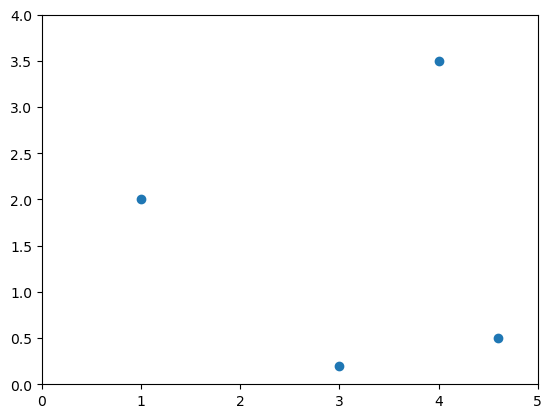

In [82]:
P = np.array([
        [3.0, 4.0, 1.0, 4.6],
        [0.2, 3.5, 2.0, 0.5]
    ])
x_coords_P, y_coords_P = P
plt.scatter(x_coords_P, y_coords_P)
plt.axis([0, 5, 0, 4])
plt.show()

Tabii aynı 4 vektörü sütun yerine satır vektörü olarak da saklayabilirdik; bu $4 \times 2$ matris olurdu ($P$'nin transpozu). Bu tamamen keyfi bir seçimdir.

Vektörler sıralı olduğu için matrisi bir yol gibi düşünebilir ve bağlı noktalarla gösterebiliriz:

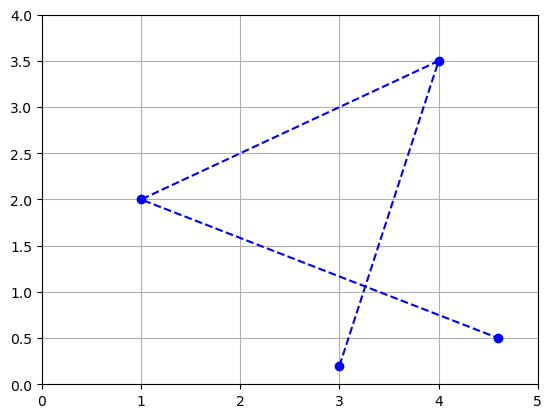

In [83]:
plt.plot(x_coords_P, y_coords_P, "bo")
plt.plot(x_coords_P, y_coords_P, "b--")
plt.axis([0, 5, 0, 4])
plt.grid()
plt.show()

Ya da bunu bir çokgen olarak gösterebilirsiniz: matplotlib'in `Polygon` sınıfı $n \times 2$ NumPy dizisi bekler, $2 \times n$ değil; bu yüzden $P^T$ vermemiz yeterli:

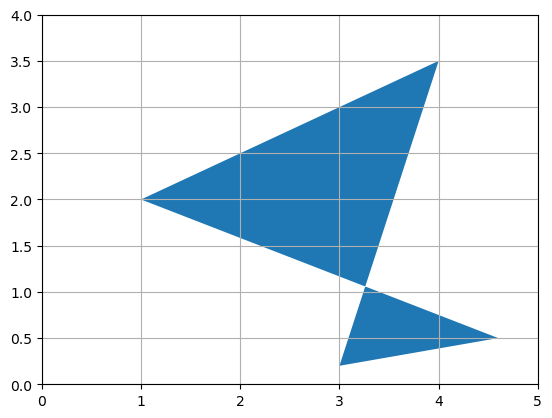

In [84]:
from matplotlib.patches import Polygon
plt.gca().add_artist(Polygon(P.T))
plt.axis([0, 5, 0, 4])
plt.grid()
plt.show()

## Matris işlemlerinin geometrik uygulamaları
Daha önce vektör toplamanın geometrik öteleme, skaler ile çarpmanın ölçekleme (orijin merkezli yakınlaştırma/uzaklaştırma) olduğunu gördük; vektör iç çarpımı ise bir vektörü başka bir vektöre projekte eder, yeniden ölçekler ve ortaya çıkan koordinatı ölçer.

Benzer şekilde matris işlemlerinin de çok kullanışlı geometrik uygulamaları vardır.

### Toplama = birden çok geometrik öteleme
Önce iki matrisi toplamak, onların tüm vektörlerini toplamakla aynıdır. Örneğin $2 \times 4$ boyutunda $H$ matrisi oluşturup $P$'ye ekleyelim ve sonuca bakalım:

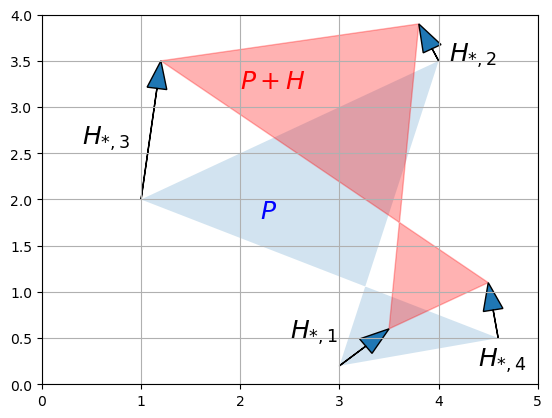

In [85]:
H = np.array([
        [ 0.5, -0.2, 0.2, -0.1],
        [ 0.4,  0.4, 1.5, 0.6]
    ])
P_moved = P + H

plt.gca().add_artist(Polygon(P.T, alpha=0.2))
plt.gca().add_artist(Polygon(P_moved.T, alpha=0.3, color="r"))
for vector, origin in zip(H.T, P.T):
    plot_vector2d(vector, origin=origin)

plt.text(2.2, 1.8, "$P$", color="b", fontsize=18)
plt.text(2.0, 3.2, "$P+H$", color="r", fontsize=18)
plt.text(2.5, 0.5, "$H_{*,1}$", color="k", fontsize=18)
plt.text(4.1, 3.5, "$H_{*,2}$", color="k", fontsize=18)
plt.text(0.4, 2.6, "$H_{*,3}$", color="k", fontsize=18)
plt.text(4.4, 0.2, "$H_{*,4}$", color="k", fontsize=18)

plt.axis([0, 5, 0, 4])
plt.grid()
plt.show()

Aynı vektörlerden oluşan bir matris eklersek basit bir geometrik öteleme elde ederiz:

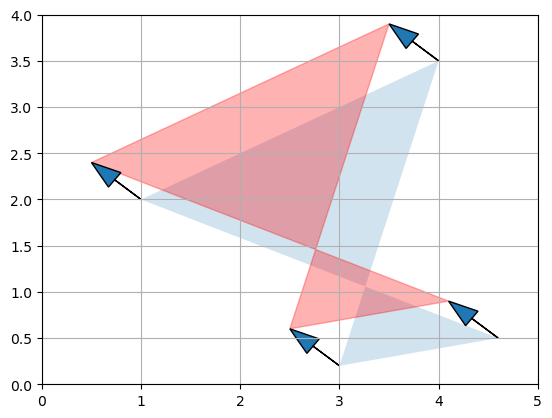

In [86]:
H2 = np.array([
        [-0.5, -0.5, -0.5, -0.5],
        [ 0.4,  0.4,  0.4,  0.4]
    ])
P_translated = P + H2

plt.gca().add_artist(Polygon(P.T, alpha=0.2))
plt.gca().add_artist(Polygon(P_translated.T, alpha=0.3, color="r"))
for vector, origin in zip(H2.T, P.T):
    plot_vector2d(vector, origin=origin)

plt.axis([0, 5, 0, 4])
plt.grid()
plt.show()

Matrisler yalnızca aynı boyuttaysa toplanabilir; ama NumPy bir matrisle satır veya sütun vektörünü toplama izni verir: buna *yayınlama* denir. Aynı sonucu şöyle de elde edebilirdik:

In [87]:
P + [[-0.5], [0.4]]  # P + H2 ile aynı, NumPy yayınlama sayesinde

array([[2.5, 3.5, 0.5, 4.1],
       [0.6, 3.9, 2.4, 0.9]])

### Skaler ile çarpma
Bir matrisi skalerle çarpmak, içindeki tüm vektörleri o skalerle çarpmak demektir; geometrik sonuç tüm şeklin yeniden ölçeklenmesidir. Örneğin çokgenimizi %60 oranında küçültelim (orijin merkezli uzaklaştırma):

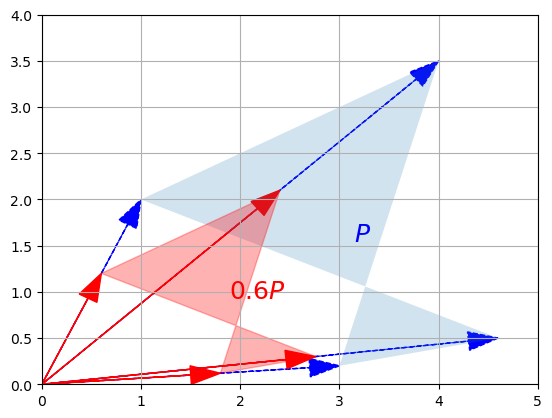

In [88]:
def plot_transformation(P_before, P_after, text_before, text_after, axis = [0, 5, 0, 4], arrows=False):
    if arrows:
        for vector_before, vector_after in zip(P_before.T, P_after.T):
            plot_vector2d(vector_before, color="blue", linestyle="--")
            plot_vector2d(vector_after, color="red", linestyle="-")
    plt.gca().add_artist(Polygon(P_before.T, alpha=0.2))
    plt.gca().add_artist(Polygon(P_after.T, alpha=0.3, color="r"))
    plt.text(P_before[0].mean(), P_before[1].mean(), text_before, fontsize=18, color="blue")
    plt.text(P_after[0].mean(), P_after[1].mean(), text_after, fontsize=18, color="red")
    plt.axis(axis)
    plt.grid()

P_rescaled = 0.60 * P
plot_transformation(P, P_rescaled, "$P$", "$0.6 P$", arrows=True)
plt.show()

### Matris çarpımı – Bir eksene projeksiyon
Matris çarpımını görselleştirmek daha zordur ama elinizdeki en güçlü araçlardan biridir.

Basit başlayalım: $1 \times 2$ boyutunda $U = \begin{bmatrix} 1 & 0 \end{bmatrix}$ matrisi tanımlayalım. Bu satır vektörü yatay birim vektördür.

In [89]:
U = np.array([[1, 0]])

Şimdi $U \cdot P$ çarpımına bakalım:

In [90]:
U.dot(P)

array([[3. , 4. , 1. , 4.6]])

Bunlar $P$ içindeki vektörlerin yatay koordinatlarıdır. Başka bir deyişle $P$'yi yatay eksene projekte ettik:

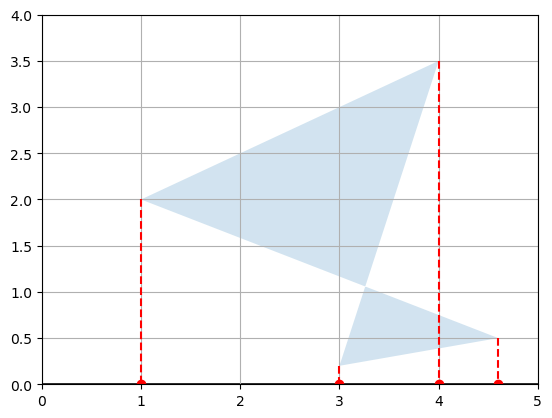

In [91]:
def plot_projection(U, P):
    U_P = U.dot(P)
    
    axis_end = 100 * U
    plot_vector2d(axis_end[0], color="black")

    plt.gca().add_artist(Polygon(P.T, alpha=0.2))
    for vector, proj_coordinate in zip(P.T, U_P.T):
        proj_point = proj_coordinate * U
        plt.plot(proj_point[0][0], proj_point[0][1], "ro")
        plt.plot([vector[0], proj_point[0][0]], [vector[1], proj_point[0][1]], "r--")

    plt.axis([0, 5, 0, 4])
    plt.grid()
    plt.show()

plot_projection(U, P)

$U$ yerine başka bir birim vektör koyarak istediğimiz eksene projeksiyon yapabiliriz. Örneğin yatay eksenin 30° üzerindeki eksene projekte edelim:

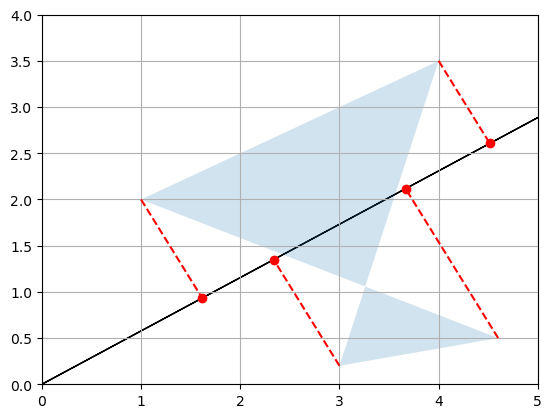

In [92]:
angle30 = 30 * np.pi / 180  # açı radyan cinsinden
U_30 = np.array([[np.cos(angle30), np.sin(angle30)]])

plot_projection(U_30, P)

Güzel! Birim vektör satırı ile matris çarpımı temelde bir eksene projeksiyon yapar ve ortaya çıkan noktaların o eksendeki koordinatlarını verir.

### Matris çarpımı – Döndürme
Yatay eksenle 30° ve 120° açı yapan iki birim vektör içeren $2 \times 2$ $V$ matrisi oluşturalım:

$V = \begin{bmatrix} \cos(30°) & \sin(30°) \\ \cos(120°) & \sin(120°) \end{bmatrix}$

In [93]:
angle120 = 120 * np.pi / 180
V = np.array([
        [np.cos(angle30), np.sin(angle30)],
        [np.cos(angle120), np.sin(angle120)]
    ])
V

array([[ 0.8660254,  0.5      ],
       [-0.5      ,  0.8660254]])

$VP$ çarpımına bakalım:

In [94]:
V.dot(P)

array([[ 2.69807621,  5.21410162,  1.8660254 ,  4.23371686],
       [-1.32679492,  1.03108891,  1.23205081, -1.8669873 ]])

İlk satır $V_{1,*} P$ olur; bu da yukarıda gördüğümüz gibi $P$'nin 30° eksenine projeksiyonunun koordinatlarıdır. İkinci satır $V_{2,*} P$'dir; $P$'nin 120° eksenine projeksiyonunun koordinatlarıdır. Yani temelde yatay ve dikey eksenleri 30° döndürdükten sonra (veya eşdeğer olarak çokgeni orijin etrafında -30° döndürdükten sonra) $P$'nin koordinatlarını elde ettik! Bunu görmek için $VP$'yi çizelim:

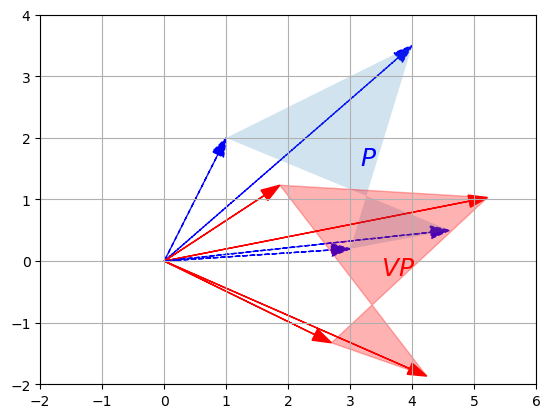

In [95]:
P_rotated = V.dot(P)
plot_transformation(P, P_rotated, "$P$", "$VP$", [-2, 6, -2, 4], arrows=True)
plt.show()

$V$ matrisine **döndürme matrisi** denir.

### Matris çarpımı – Diğer doğrusal dönüşümler
Daha genel olarak, n boyutlu vektörleri m boyutlu vektörlere dönüştüren herhangi bir doğrusal dönüşüm $f$, bir $m \times n$ matrisle temsil edilebilir. Örneğin $\textbf{u}$ 3 boyutlu bir vektör olsun:

$\textbf{u} = \begin{pmatrix} x \\ y \\ z \end{pmatrix}$

$f$ şöyle tanımlansın:

$f(\textbf{u}) = \begin{pmatrix}
ax + by + cz \\
dx + ey + fz
\end{pmatrix}$

Bu $f$ dönüşümü 3 boyutlu vektörleri 2 boyutlu vektörlere doğrusal biçimde eşler (sonuç koordinatlar yalnızca orijinal koordinatların katlarının toplamlarını içerir). Bu dönüşümü $F$ matrisiyle temsil edebiliriz:

$F = \begin{bmatrix}
a & b & c \\
d & e & f
\end{bmatrix}$

$f(\textbf{u})$ hesaplamak için matris çarpımı yeterlidir:

$f(\textbf{u}) = F \textbf{u}$

$G = \begin{bmatrix}\textbf{u}_1 & \textbf{u}_2 & \cdots & \textbf{u}_q \end{bmatrix}$ matrisi olsun; her $\textbf{u}_i$ 3 boyutlu sütun vektörü. $FG$, $F$ matrisinin tanımladığı doğrusal dönüşümü tüm $\textbf{u}_i$ vektörlerine uygular:

$FG = \begin{bmatrix}f(\textbf{u}_1) & f(\textbf{u}_2) & \cdots & f(\textbf{u}_q) \end{bmatrix}$

Özetle, matris çarpımında sol taraftaki matris, sağdaki vektörlere hangi doğrusal dönüşümün uygulanacağını belirler. Projeksiyon ve döndürme için kullanılabileceğini gösterdik; başka doğrusal dönüşümler de mümkündür. Örneğin *kaydırma eşlemesi* adı verilen bir dönüşüm:

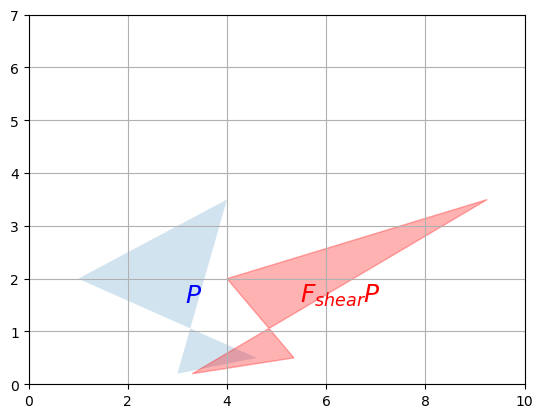

In [96]:
F_shear = np.array([
        [1, 1.5],
        [0, 1]
    ])
plot_transformation(P, F_shear.dot(P), "$P$", "$F_{shear} P$",
                    axis=[0, 10, 0, 7])
plt.show()

Bu dönüşümün **birim kare** üzerindeki etkisine bakalım:

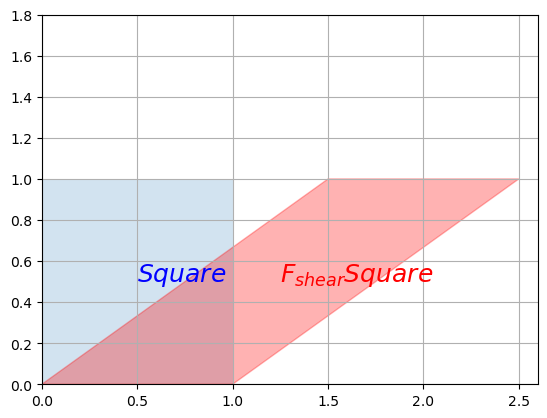

In [97]:
Square = np.array([
        [0, 0, 1, 1],
        [0, 1, 1, 0]
    ])
plot_transformation(Square, F_shear.dot(Square), "$Square$", "$F_{shear} Square$",
                    axis=[0, 2.6, 0, 1.8])
plt.show()

Şimdi bir **sıkıştırma eşlemesine** bakalım:

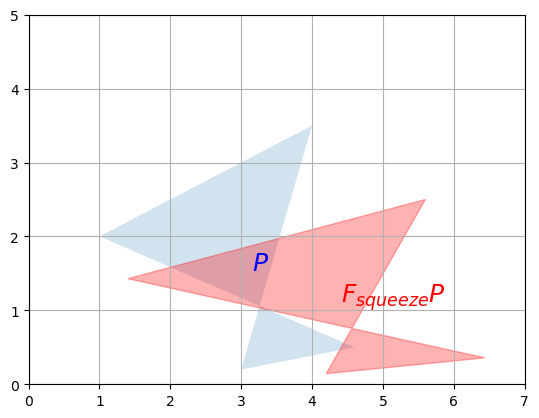

In [98]:
F_squeeze = np.array([
        [1.4, 0],
        [0, 1/1.4]
    ])
plot_transformation(P, F_squeeze.dot(P), "$P$", "$F_{squeeze} P$",
                    axis=[0, 7, 0, 5])
plt.show()

Birim kare üzerindeki etkisi:

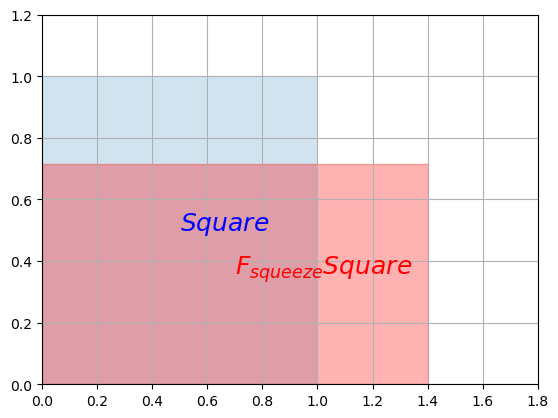

In [99]:
plot_transformation(Square, F_squeeze.dot(Square), "$Square$", "$F_{squeeze} Square$",
                    axis=[0, 1.8, 0, 1.2])
plt.show()

Son bir tane daha: yatay eksen üzerinden yansıma:

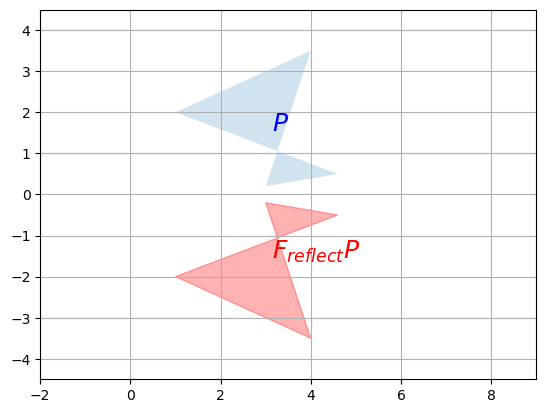

In [100]:
F_reflect = np.array([
        [1, 0],
        [0, -1]
    ])
plot_transformation(P, F_reflect.dot(P), "$P$", "$F_{reflect} P$",
                    axis=[-2, 9, -4.5, 4.5])
plt.show()

## Matris tersi
Bir matrisin herhangi bir doğrusal dönüşümü temsil edebileceğini anladığımıza göre doğal bir soru: verilen $F$ dönüşüm matrisinin etkisini geri alan bir dönüşüm matrisi bulabilir miyiz? Cevap evet… bazen! Var olduğunda buna $F$ matrisinin **tersi** denir ve $F^{-1}$ ile gösterilir.

Örneğin yukarıdaki döndürme, kaydırma eşlemesi ve sıkıştırma eşlemesinin hepsinin ters dönüşümleri vardır. Bunu kaydırma eşlemesinde gösterelim:

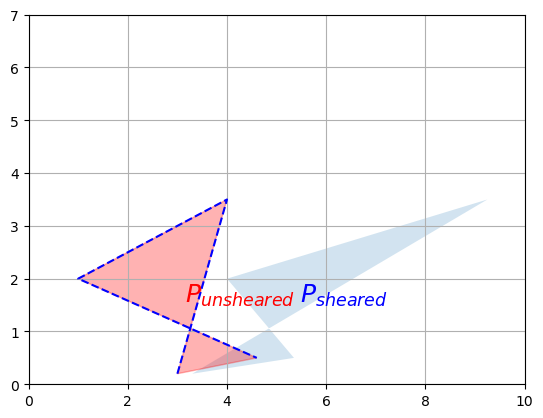

In [101]:
F_inv_shear = np.array([
    [1, -1.5],
    [0, 1]
])
P_sheared = F_shear.dot(P)
P_unsheared = F_inv_shear.dot(P_sheared)
plot_transformation(P_sheared, P_unsheared, "$P_{sheared}$", "$P_{unsheared}$",
                    axis=[0, 10, 0, 7])
plt.plot(P[0], P[1], "b--")
plt.show()

$P$'ye daha önce yaptığımız gibi kaydırma eşlemesi uyguladık, sonra sonuca ikinci bir dönüşüm uyguladık ve orijinal $P$'ye döndük (orijinal $P$'nin dış çizgisini çizerek doğruladık). İkinci dönüşüm birincinin tersidir.

Ters matris $F_{shear}^{-1}$'i bu sefer elle tanımladık; NumPy `inv` fonksiyonu matris tersini hesaplar, şunu da yazabilirdik:

In [102]:
F_inv_shear = LA.inv(F_shear)
F_inv_shear

array([[ 1. , -1.5],
       [ 0. ,  1. ]])

Yalnızca kare matrislerin tersi alınabilir. Düşününce mantıklı: boyut sayısını azaltan bir dönüşümde bilgi kaybolur ve geri almanın yolu yoktur. Örneğin 3B nesneyi düzleme projekte eden $2 \times 3$ matris kullandığınızı varsayın. Sonuç şöyle görünebilir:

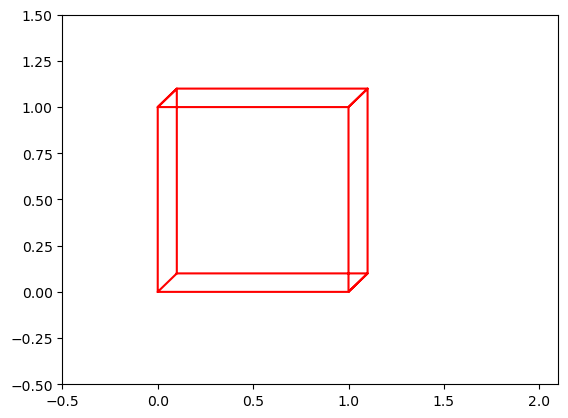

In [103]:
plt.plot([0, 0, 1, 1, 0, 0.1, 0.1, 0, 0.1, 1.1, 1.0, 1.1, 1.1, 1.0, 1.1, 0.1],
         [0, 1, 1, 0, 0, 0.1, 1.1, 1.0, 1.1, 1.1, 1.0, 1.1, 0.1, 0, 0.1, 0.1],
         "r-")
plt.axis([-0.5, 2.1, -0.5, 1.5])
plt.show()

Bu görüntüye bakarak bunun bir küpün mü yoksa dar bir dikdörtgen prizmanın mı projeksiyonu olduğunu söylemek imkansızdır. Projeksiyonda bilgi kaybolmuştur.

Kare dönüşüm matrisleri bile bilgi kaybedebilir. Örneğin şu dönüşüm matrisine bakın:

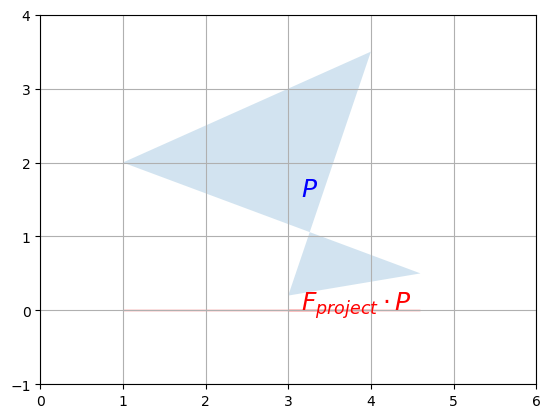

In [104]:
F_project = np.array([
        [1, 0],
        [0, 0]
    ])
plot_transformation(P, F_project.dot(P), "$P$", "$F_{project} \cdot P$",
                    axis=[0, 6, -1, 4])
plt.show()

Bu dönüşüm matrisi yatay eksene projeksiyon yapar. Çokgenimiz tamamen düzleşir; bilgi tamamen kaybolur ve doğrusal dönüşümle orijinal çokgene dönmek imkansızdır. Başka bir deyişle $F_{project}$'in tersi yoktur. Tersi alınamayan kare matrise **tekil matris** (dejenere matris) denir. NumPy'den tersini hesaplamasını istersek hata fırlatır:

In [105]:
try:
    LA.inv(F_project)
except LA.LinAlgError as e:
    print("LinAlgError:", e)

LinAlgError: Singular matrix


Başka bir tekil matris örneği: yatay eksenin 30° üzerindeki eksene projeksiyon yapar:

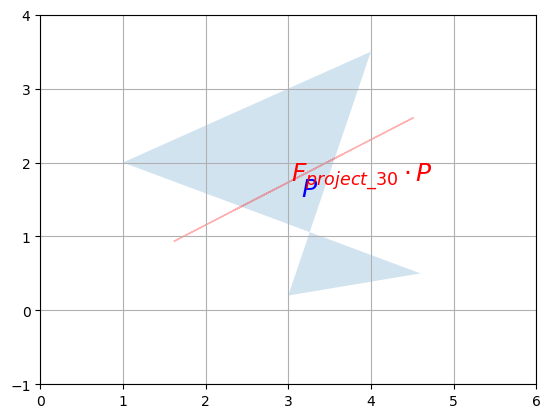

In [106]:
angle30 = 30 * np.pi / 180
F_project_30 = np.array([
               [np.cos(angle30)**2, np.sin(2*angle30)/2],
               [np.sin(2*angle30)/2, np.sin(angle30)**2]
         ])
plot_transformation(P, F_project_30.dot(P), "$P$", "$F_{project\_30} \cdot P$",
                    axis=[0, 6, -1, 4])
plt.show()

Ama bu sefer kayan nokta yuvarlama hataları nedeniyle NumPy bir ters hesaplayabildi (elemanların ne kadar büyük olduğuna bakın):

In [107]:
LA.inv(F_project_30)

array([[ 1.54810441e+16, -2.68139549e+16],
       [-2.68139549e+16,  4.64431323e+16]])

Beklediğiniz gibi, bir matrisin kendi tersiyle çarpımı birim matrisi verir:

$M \cdot M^{-1} = M^{-1} \cdot M = I$

Doğrusal dönüşüm ardından ters dönüşüm uygulamanın hiçbir değişiklik yapmaması mantıklıdır.

In [108]:
F_shear.dot(LA.inv(F_shear))

array([[1., 0.],
       [0., 1.]])

Bir matrisin tersinin tersi, matrisin kendisidir:

$((M)^{-1})^{-1} = M$

In [109]:
LA.inv(LA.inv(F_shear))

array([[1. , 1.5],
       [0. , 1. ]])

$\lambda$ katsayısıyla ölçeklemenin tersi tabii ki $\frac{1}{\lambda}$ katsayısıyla ölçeklemedir:

$ (\lambda \times M)^{-1} = \frac{1}{\lambda} \times M^{-1}$

Matrisleri doğrusal dönüşüm olarak yorumladığınızda bu özelliklerin çoğu sezgisel gelir.

Kendi tersine eşit matrise **involüsyon** denir. En basit örnekler yansıma matrisleri veya 180° döndürme; daha karmaşık involüsyonlar da vardır — yatay sıkıştırma, dikey eksen üzerinden yansıma ve 90° saat yönünde döndürme yapan bir dönüşümü hayal edin. Bir peçeteyi iki kez deneyin: başlangıç konumuna dönersiniz. İlgili involüsyon matrisi:

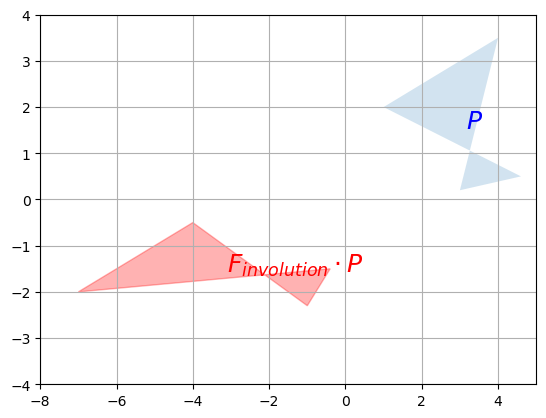

In [110]:
F_involution  = np.array([
        [0, -2],
        [-1/2, 0]
    ])
plot_transformation(P, F_involution.dot(P), "$P$", "$F_{involution} \cdot P$",
                    axis=[-8, 5, -4, 4])
plt.show()

Son olarak, tersi kendi transpozuna eşit olan kare $H$ matrisi **ortogonal matristir**:

$H^{-1} = H^T$

Dolayısıyla:

$H \cdot H^T = H^T \cdot H = I$

Döndürme ve yansıma gibi mesafeleri koruyan dönüşümlere karşılık gelir; ölçekleme, kaydırma veya sıkıştırma değil. $F_{reflect}$'in ortogonal olduğunu doğrulayalım:

In [111]:
F_reflect.dot(F_reflect.T)

array([[1, 0],
       [0, 1]])

## Determinant
Bir kare matrisin determinantı $\det(M)$ veya $\det M$ ya da $|M|$ ile gösterilir; elemanlarından $(M_{i,j})$ çeşitli eşdeğer yöntemlerle hesaplanır. En basit yöntemlerden biri özyinelemeli yaklaşımdır:

$|M| = M_{1,1}\times|M^{(1,1)}| - M_{2,1}\times|M^{(2,1)}| + M_{3,1}\times|M^{(3,1)}| - M_{4,1}\times|M^{(4,1)}| + \cdots ± M_{n,1}\times|M^{(n,1)}|$

* $M^{(i,j)}$, $M$ matrisinin $i$'inci satırı ve $j$'inci sütunu çıkarılmış halidir.

Örneğin şu $3 \times 3$ matrisin determinantını hesaplayalım:

$M = \begin{bmatrix}
 1 & 2 & 3 \\
 4 & 5 & 6 \\
 7 & 8 & 0
\end{bmatrix}$

Yukarıdaki yöntemle:

$|M| = 1 \times \left | \begin{bmatrix} 5 & 6 \\ 8 & 0 \end{bmatrix} \right |
 - 2 \times \left | \begin{bmatrix} 4 & 6 \\ 7 & 0 \end{bmatrix} \right |
 + 3 \times \left | \begin{bmatrix} 4 & 5 \\ 7 & 8 \end{bmatrix} \right |$

Şimdi bu $2 \times 2$ matrislerin determinantlarını hesaplamamız gerekir (bunlara **minör** denir):

$\left | \begin{bmatrix} 5 & 6 \\ 8 & 0 \end{bmatrix} \right | = 5 \times 0 - 6 \times 8 = -48$

$\left | \begin{bmatrix} 4 & 6 \\ 7 & 0 \end{bmatrix} \right | = 4 \times 0 - 6 \times 7 = -42$

$\left | \begin{bmatrix} 4 & 5 \\ 7 & 8 \end{bmatrix} \right | = 4 \times 8 - 5 \times 7 = -3$

Sonuç:

$|M| = 1 \times (-48) - 2 \times (-42) + 3 \times (-3) = 27$

Bir matrisin determinantını almak için `numpy.linalg` modülündeki `det` fonksiyonunu çağırabilirsiniz:

In [112]:
M = np.array([
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 0]
    ])
LA.det(M)

np.float64(27.0)

Determinantın temel kullanım alanlarından biri, kare bir matrisin tersinin olup olmadığını anlamaktır: determinant 0 ise matrisin tersi *alınamaz* (tekil matristir); 0 değilse tersi *alınabilir*.

Örneğin daha önce tanımladığımız $F_{project}$, $F_{project\_30}$ ve $F_{shear}$ matrislerinin determinantını hesaplayalım:

In [113]:
LA.det(F_project)

np.float64(0.0)

Doğru, $F_{project}$ tekil; daha önce gördük.

In [114]:
LA.det(F_project_30)

np.float64(1.6148781609251353e-17)

Bu determinant şüpheli biçimde 0'a yakın: aslında 0 olmalı ama küçük kayan nokta hataları yüzünden değil. Matris gerçekten tekil.

In [115]:
LA.det(F_shear)

np.float64(1.0)

Mükemmel! Bu matrisin tersi alınabilir; daha önce gördük. Matematik gerçekten işe yarıyor!

Determinant, bir doğrusal dönüşümün yüzey alanını ne kadar değiştirdiğini ölçmek için de kullanılabilir: örneğin $F_{project}$ ve $F_{project\_30}$ projeksiyon matrisleri $P$ çokgenini tamamen düzleştirir, alanı sıfır olur. Bu yüzden bu matrislerin determinantı 0'dır. Kaydırma eşlemesi çokgenin şeklini değiştirdi ama yüzey alanını etkilemedi; determinant 1'dir. Döndürme matrisinin determinantını hesaplayın; 1 bulmalısınız. Ölçekleme matrisi peki? Bakalım:

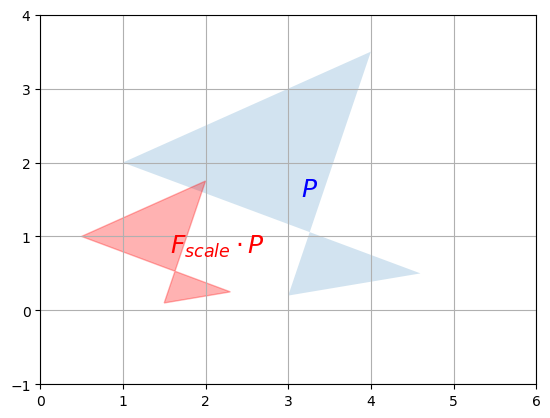

In [116]:
F_scale = np.array([
        [0.5, 0],
        [0, 0.5]
    ])
plot_transformation(P, F_scale.dot(P), "$P$", "$F_{scale} \cdot P$",
                    axis=[0, 6, -1, 4])
plt.show()

Çokgeni hem dikey hem yatay eksende 1/2 katsayısıyla ölçekledik; sonuç çokgenin yüzey alanı orijinalin 1/4'ü. Determinantı hesaplayıp doğrulayalım:

In [117]:
LA.det(F_scale)

np.float64(0.25)

Doğru!

Dönüşüm şekli ters çevirdiğinde determinant negatif olabilir (örneğin sol el eldiveni sağ el eldivenine döner). `F_reflect` matrisinin determinantı -1'dir çünkü yüzey alanı korunur ama çokgen ters çevrilir:

In [118]:
LA.det(F_reflect)

np.float64(-1.0)

## Doğrusal dönüşümleri birleştirme
Birden çok doğrusal dönüşümü art arda matris çarpımı yaparak birleştirebiliriz. Örneğin önce sıkıştırma eşlemesi sonra kaydırma eşlemesi uygulamak için:

In [119]:
P_squeezed_then_sheared = F_shear.dot(F_squeeze.dot(P))

Matris çarpımı birleşme özelliğine sahip olduğundan şu kod eşdeğerdir:

In [120]:
P_squeezed_then_sheared = (F_shear.dot(F_squeeze)).dot(P)

Dönüşümlerin sırasının matris çarpımı sırasının tersi olduğuna dikkat edin.

Bu birleşik dönüşümü birden fazla kez uygulayacaksak birleşim matrisini kaydetmek mantıklı:

In [121]:
F_squeeze_then_shear = F_shear.dot(F_squeeze)
P_squeezed_then_sheared = F_squeeze_then_shear.dot(P)

Bundan sonra her iki dönüşümü tek matris çarpımında yapabiliriz; bu ciddi performans kazancı sağlayabilir.

Bu çift dönüşümün tersini uygulamak isterseniz? Sıkıştırdıysanız ve kaydırdıysanız, geri almak için önce kaydırmayı geri alıp sonra sıkıştırmayı geri almanız gerekir. Daha matematiksel olarak, terslenebilir (tekil olmayan) $Q$ ve $R$ matrisleri için:

$(Q \cdot R)^{-1} = R^{-1} \cdot Q^{-1}$

NumPy'de:

In [122]:
LA.inv(F_shear.dot(F_squeeze)) == LA.inv(F_squeeze).dot(LA.inv(F_shear))

array([[ True,  True],
       [ True,  True]])

## Tekil değer ayrışımı (SVD)
Herhangi bir $m \times n$ matris $M$, üç basit matrisin çarpımına ayrıştırılabilir:
* bir $U$ döndürme matrisi ($m \times m$ ortogonal matris)
* bir $\Sigma$ ölçekleme ve projeksiyon matrisi ($m \times n$ köşegen matris)
* bir $V^T$ döndürme matrisi ($n \times n$ ortogonal matris)

$M = U \cdot \Sigma \cdot V^{T}$

Örneğin kaydırma dönüşümünü ayrıştıralım:

In [123]:
U, S_diag, V_T = LA.svd(F_shear) # not: Python 3'te S_diag'i Σ_diag olarak yeniden adlandırabilirsiniz
U

array([[ 0.89442719, -0.4472136 ],
       [ 0.4472136 ,  0.89442719]])

In [124]:
S_diag

array([2. , 0.5])

Not: bu yalnızca Σ'nin köşegen değerlerini içeren 1B dizidir. Gerçek Σ matrisini almak için NumPy'nin `diag` fonksiyonunu kullanabiliriz:

In [125]:
S = np.diag(S_diag)
S

array([[2. , 0. ],
       [0. , 0.5]])

$U \cdot \Sigma \cdot V^T$'nin gerçekten `F_shear`'a eşit olduğunu doğrulayalım:

In [126]:
U.dot(np.diag(S_diag)).dot(V_T)

array([[ 1.00000000e+00,  1.50000000e+00],
       [-1.25949234e-17,  1.00000000e+00]])

In [127]:
F_shear

array([[1. , 1.5],
       [0. , 1. ]])

Harika çalıştı. Birim kareye bu dönüşümleri tek tek (ters sırada) uygulayarak ne olduğunu anlayalım. Önce ilk döndürme $V^T$:

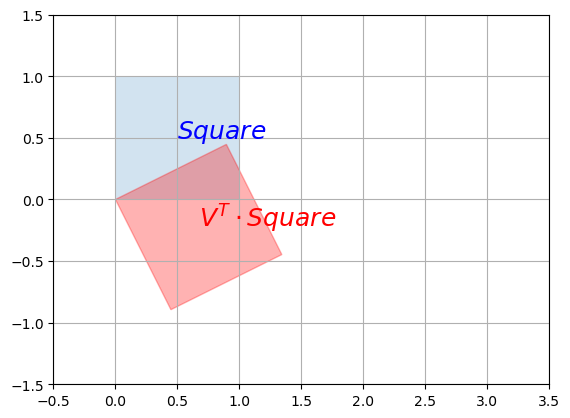

In [128]:
plot_transformation(Square, V_T.dot(Square), "$Square$", "$V^T \cdot Square$",
                    axis=[-0.5, 3.5 , -1.5, 1.5])
plt.show()

Şimdi $\Sigma$ ile dikey ve yatay eksenler boyunca ölçekleyelim:

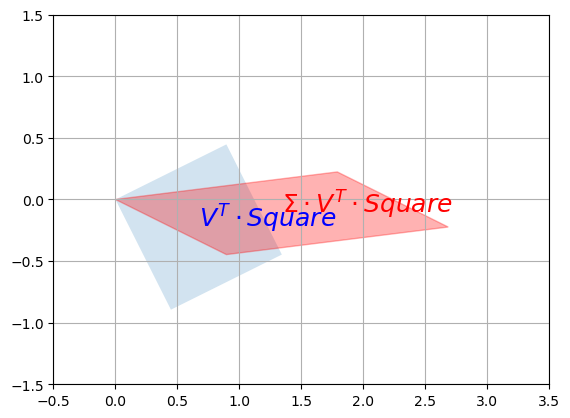

In [129]:
plot_transformation(V_T.dot(Square), S.dot(V_T).dot(Square), "$V^T \cdot Square$", "$\Sigma \cdot V^T \cdot Square$",
                    axis=[-0.5, 3.5 , -1.5, 1.5])
plt.show()

Son olarak ikinci döndürme $U$:

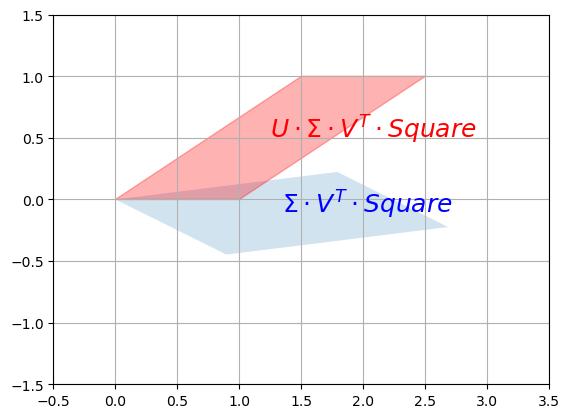

In [130]:
plot_transformation(S.dot(V_T).dot(Square), U.dot(S).dot(V_T).dot(Square),"$\Sigma \cdot V^T \cdot Square$", "$U \cdot \Sigma \cdot V^T \cdot Square$",
                    axis=[-0.5, 3.5 , -1.5, 1.5])
plt.show()

Sonucun gerçekten orijinal birim karenin kaydırma eşlemesi olduğunu görebiliriz.

## Özvektörler ve özdeğerler
Bir kare matrisin **özvektörü** (ya da karakteristik vektör), dönüşümden sonra aynı doğru üzerinde kalan sıfır olmayan vektördür. Daha biçimsel tanım: $\lambda$ skaleriyle ilişkili **özdeğer** olmak üzere

$M \cdot v = \lambda \times v$

koşulunu sağlayan her $v$ vektörü.

Örneğin yatay vektörler kaydırma eşlemesinden sonra yatay kalır (yukarıdaki şekilde görebilirsiniz); $M$'nin özvektörüdür. Dikey vektör sağa eğilir; dikey vektörler $M$'nin özvektörü *değildir*.

Sıkıştırma eşlemesine bakarsak yatay veya dikey vektörler yönlerini korur (uzunlukları değişir); tüm yatay ve dikey vektörler $F_{squeeze}$'nin özvektörüdür.

Ancak döndürme matrislerinin hiç özvektörü yoktur (döndürme açısı 0° veya 180° değilse; o durumda sıfır olmayan tüm vektörler özvektördür).

NumPy'nin `eig` fonksiyonu kare matrisler için birim özvektör listesi ve karşılık gelen özdeğerleri döndürür. $F_{squeeze}$ matrisinin özvektör ve özdeğerlerine bakalım:

In [131]:
eigenvalues, eigenvectors = LA.eig(F_squeeze)
eigenvalues # [λ0, λ1, …]

array([1.4       , 0.71428571])

In [132]:
eigenvectors # [v0, v1, …]

array([[1., 0.],
       [0., 1.]])

Yatay vektörler gerçekten 1,4 katına uzatılmış, dikey vektörler 1/1,4 ≈ 0,714 katına kısaltılmış; güzel. $F_{shear}$ matrisine bakalım:

In [133]:
eigenvalues2, eigenvectors2 = LA.eig(F_shear)
eigenvalues2 # [λ0, λ1, …]

array([1., 1.])

In [134]:
eigenvectors2 # [v0, v1, …]

array([[ 1.00000000e+00, -1.00000000e+00],
       [ 0.00000000e+00,  1.48029737e-16]])

Bekle, ne!? Yalnızca bir birim özvektör bekliyorduk, iki tane geldi. İkinci vektör neredeyse $\begin{pmatrix}-1 \\ 0 \end{pmatrix}$; bu $\begin{pmatrix}1 \\ 0 \end{pmatrix}$ ile aynı doğru üzerinde. Kayan nokta hatalarından kaynaklanıyor. (Neredeyse) doğrusal vektörleri güvenle yok sayabiliriz.

## İz
Bir kare matrisin izi $tr(M)$ ile gösterilir ve ana köşegenindeki değerlerin toplamıdır. Örneğin:

In [135]:
D = np.array([
        [100, 200, 300],
        [ 10,  20,  30],
        [  1,   2,   3],
    ])
np.trace(D)

np.int64(123)

İz genelde basit bir geometrik yorumu yoktur ama birçok alanda yararlı özellikleri vardır:
* $tr(A + B) = tr(A) + tr(B)$
* $tr(A \cdot B) = tr(B \cdot A)$
* $tr(A \cdot B \cdot \cdots \cdot Y \cdot Z) = tr(Z \cdot A \cdot B \cdot \cdots \cdot Y)$
* $tr(A^T \cdot B) = tr(A \cdot B^T) = tr(B^T \cdot A) = tr(B \cdot A^T) = \sum_{i,j}X_{i,j} \times Y_{i,j}$
* …

Ancak projeksiyon matrisleri ($F_{project}$ gibi) için yararlı bir geometrik yorumu vardır: projeksiyondan sonra kalan boyut sayısına karşılık gelir. Örneğin:

In [136]:
np.trace(F_project)

np.int64(1)

# Sonra ne?
Doğrusal cebire giriş burada bitiyor. Bu temel bilgiler makine öğrenmesi için çoğu zaman yeterlidir; daha derinlemesine gitmek isterseniz üniversite ders kitapları ve çevrimiçi ders notları iyi bir başlangıç noktası olabilir.